In [15]:
import pandas as pd
path = "https://raw.githubusercontent.com/ulka29/paper/7aad80ab3fe4ad5ffeabffb7c30bcb70edb218bd/01_data/processed/df_cleaned.csv"# import Check dataset
df= pd.read_csv(path)
df.head()

,tweet_text,cyberbullying_type,clean_tweet,lemmatized_tweet,sentiment_scores,negative,positive,neutral,compound
0,"in other words #katandandre, your food was cra...",not_cyberbullying,words katandandre food crapilicious mkr,word katandandre food crapilicious mkr,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000,1.000,0.0000
1,why is #aussietv so white? #mkr #theblock #ima...,not_cyberbullying,aussietv white mkr theblock imacelebrityau tod...,aussietv white mkr theblock imacelebrityau tod...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,0.000,1.000,0.0000
2,@xochitlsuckkks a classy whore? or more red ve...,not_cyberbullying,classy whore red velvet cupcakes,classy whore red velvet cupcake,"{'neg': 0.32, 'neu': 0.481, 'pos': 0.199, 'com...",0.320,0.199,0.481,-0.4137
3,"@jason_gio meh. :p thanks for the heads up, b...",not_cyberbullying,meh p thanks heads concerned another angry dud...,meh p thanks head concerned another angry dude...,"{'neg': 0.243, 'neu': 0.607, 'pos': 0.15, 'com...",0.243,0.150,0.607,-0.4854
4,@rudhoeenglish this is an isis account pretend...,not_cyberbullying,isis account pretending kurdish account like i...,isi account pretending kurdish account like is...,"{'neg': 0.129, 'neu': 0.691, 'pos': 0.18, 'com...",0.129,0.180,0.691,0.0258


In [16]:
# Select relevant features for SA + ML
df_ml = df[
    [
        'lemmatized_tweet',
        'negative',
        'positive',
        'neutral',
        'compound',
        'cyberbullying_type'
    ]
].copy()

# Check shape
print("\n:-------------Shape::-------------", df_ml.shape)

# Check column names
print("\n:-------------Columns::-------------")
print(df_ml.columns.tolist())

# Check missing values
print("\n----------------Missing values:-------------")
print(df_ml.isnull().sum())

# Display first 5 rows
df_ml.head()


:-------------Shape::------------- (42645, 6)

:-------------Columns::-------------
['lemmatized_tweet', 'negative', 'positive', 'neutral', 'compound', 'cyberbullying_type']

----------------Missing values:-------------
lemmatized_tweet      30
negative               0
positive               0
neutral                0
compound               0
cyberbullying_type     0
dtype: int64


,lemmatized_tweet,negative,positive,neutral,compound,cyberbullying_type
0,word katandandre food crapilicious mkr,0.000,0.000,1.000,0.0000,not_cyberbullying
1,aussietv white mkr theblock imacelebrityau tod...,0.000,0.000,1.000,0.0000,not_cyberbullying
2,classy whore red velvet cupcake,0.320,0.199,0.481,-0.4137,not_cyberbullying
3,meh p thanks head concerned another angry dude...,0.243,0.150,0.607,-0.4854,not_cyberbullying
4,isi account pretending kurdish account like is...,0.129,0.180,0.691,0.0258,not_cyberbullying


*  Input = lemmetized text + sentiment feature
*  Output = cyberbully type => label encoding (0-5)
*  train test split = 70-30, stratify=y_encoded
*  TFidf on lemmetized text = max feature = feature column = 10000, ngram (1,2)
*  smote applied = each class same number of sample in training by synthetic data generation for minority class


Classes:
['age' 'ethnicity' 'gender' 'not_cyberbullying' 'other_cyberbullying'
 'religion']

Label Mapping:
0 → age
1 → ethnicity
2 → gender
3 → not_cyberbullying
4 → other_cyberbullying
5 → religion

Train-Test Split
-------------------------
Training samples: 29851
Testing samples : 12794

TF-IDF Features
-------------------------
X_train TF-IDF: (29851, 10000)
X_test TF-IDF : (12794, 10000)

Combined Features
-------------------------
X_train: (29851, 10004)
X_test : (12794, 10004)

Class Distribution BEFORE SMOTE
--------------------------------
age                       : 5570
ethnicity                 : 5199
gender                    : 5243
not_cyberbullying         : 4511
other_cyberbullying       : 3753
religion                  : 5575

Class Distribution AFTER SMOTE
-------------------------------
age                       : 5575
ethnicity                 : 5575
gender                    : 5575
not_cyberbullying         : 5575
other_cyberbullying       : 5575
religion         

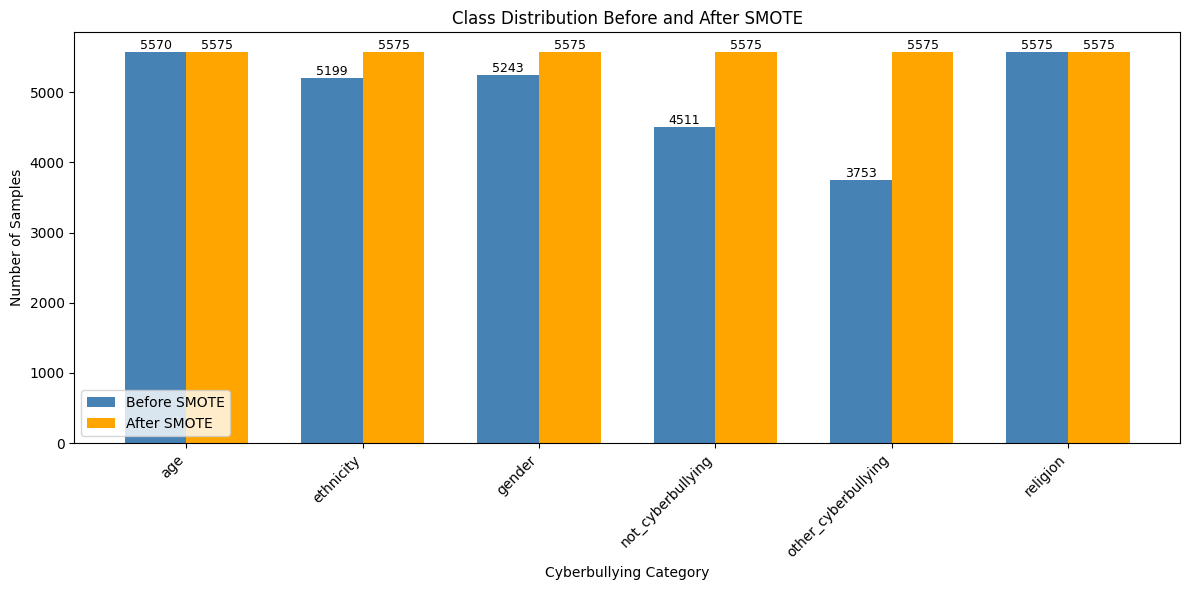

In [14]:
# ============================================================
# CELL 1: DATA PREPARATION
# TF-IDF + SENTIMENT ANALYSIS + SMOTE
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. TEXT, SENTIMENT FEATURES AND TARGET
# ------------------------------------------------------------

X_text = df['lemmatized_tweet'].fillna('')
# Sentiment Analysis features
sentiment_features = [
    'negative',
    'positive',
    'neutral',
    'compound'
]

X_sentiment = df[sentiment_features].fillna(0)

# Target variable
y = df['cyberbullying_type']

# ------------------------------------------------------------
# 2. LABEL ENCODING
# ------------------------------------------------------------

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

# Label mapping
label_mapping = dict(
    enumerate(label_encoder.classes_)
)

print("\nLabel Mapping:")

for number, category in label_mapping.items():
    print(f"{number} → {category}")

# ------------------------------------------------------------
# 3. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_text_train, X_text_test, X_sent_train, X_sent_test, y_train, y_test = train_test_split(
    X_text,
    X_sentiment,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain-Test Split")
print("-------------------------")
print("Training samples:", len(X_text_train))
print("Testing samples :", len(X_text_test))

# ------------------------------------------------------------
# 4. TF-IDF VECTORIZATION
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

print("\nTF-IDF Features")
print("-------------------------")
print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF :", X_test_tfidf.shape)

# ------------------------------------------------------------
# 5. COMBINE TF-IDF + SENTIMENT FEATURES
# ------------------------------------------------------------

X_train_combined = hstack([
    X_train_tfidf,
    X_sent_train.values
])

X_test_combined = hstack([
    X_test_tfidf,
    X_sent_test.values
])

print("\nCombined Features")
print("-------------------------")
print("X_train:", X_train_combined.shape)
print("X_test :", X_test_combined.shape)

# ------------------------------------------------------------
# 6. CLASS DISTRIBUTION BEFORE SMOTE
# ------------------------------------------------------------

print("\nClass Distribution BEFORE SMOTE")
print("--------------------------------")

before_smote = Counter(y_train)

for class_id, count in sorted(before_smote.items()):
    print(
        f"{label_encoder.classes_[class_id]:<25} : {count}"
    )

# ------------------------------------------------------------
# 7. SMOTE
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 8. CLASS DISTRIBUTION AFTER SMOTE
# ------------------------------------------------------------

print("\nClass Distribution AFTER SMOTE")
print("-------------------------------")

after_smote = Counter(y_train_smote)

for class_id, count in sorted(after_smote.items()):
    print(
        f"{label_encoder.classes_[class_id]:<25} : {count}"
    )

print("\nAfter SMOTE")
print("-------------------------")
print("X_train:", X_train_smote.shape)
print("y_train:", y_train_smote.shape)

# ------------------------------------------------------------
# 9. CATEGORY-WISE COMPARISON
# ------------------------------------------------------------

categories = label_encoder.classes_

before_counts = [
    before_smote[i]
    for i in range(len(categories))
]

after_counts = [
    after_smote[i]
    for i in range(len(categories))
]



# ------------------------------------------------------------
# 10. BAR CHART
# ------------------------------------------------------------

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    before_counts,
    width,
    label='Before SMOTE',
    color='steelblue'
)

bars2 = plt.bar(
    x + width / 2,
    after_counts,
    width,
    label='After SMOTE',
    color='orange'
)

plt.xlabel('Cyberbullying Category')
plt.ylabel('Number of Samples')
plt.title('Class Distribution Before and After SMOTE')

plt.xticks(
    x,
    categories,
    rotation=45,
    ha='right'
)

plt.legend()

# Add values on bars
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(int(height)),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

## Training Data
*   TF-IDF ONLY + NO BALANCING + LOGISTIC REGRESSION
*   TF-IDF + SA + No Balancing + LOGISTIC REGRESSION
*   TF-IDF + SA + Class Weight + LOGISTIC REGRESSION
*   TF-IDF + SA + SMOTE + LOGISTIC REGRESSION

Training TF-IDF Only + Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Parameters:
{'C': 1}

Best Cross-Validation Weighted F1:
0.8426

TF-IDF ONLY + NO BALANCING
Accuracy     : 0.8487
Weighted F1  : 0.8497
Macro F1     : 0.8298

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      2387
          ethnicity       0.97      0.98      0.98      2228
             gender       0.92      0.85      0.88      2248
  not_cyberbullying       0.60      0.63      0.61      1934
other_cyberbullying       0.59      0.59      0.59      1608
           religion       0.96      0.95      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.85      0.85      0.85     12794



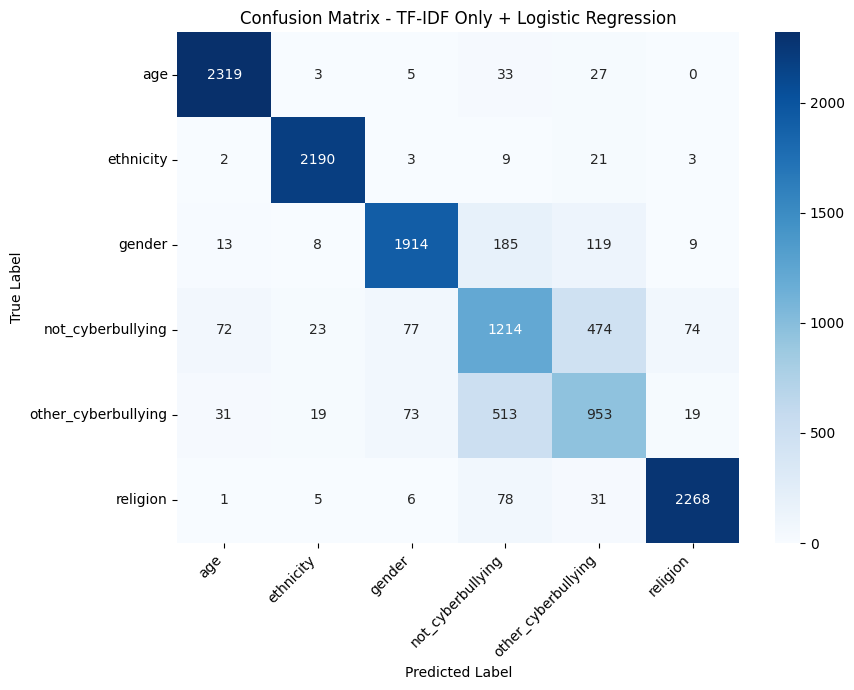

In [17]:
# ============================================================
# TF-IDF ONLY + NO BALANCING + LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_tfidf = GridSearchCV(
    estimator=lr_tfidf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL TF-IDF DATA
# ------------------------------------------------------------

print("Training TF-IDF Only + Logistic Regression...")

grid_tfidf.fit(
    X_train_tfidf,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_tfidf = grid_tfidf.best_estimator_

print("\nBest Parameters:")
print(grid_tfidf.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_tfidf.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION ON TEST DATA
# ------------------------------------------------------------

y_pred_tfidf = best_tfidf.predict(
    X_test_tfidf
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf
)

tfidf_weighted_f1 = f1_score(
    y_test,
    y_pred_tfidf,
    average='weighted'
)

tfidf_macro_f1 = f1_score(
    y_test,
    y_pred_tfidf,
    average='macro'
)

# ------------------------------------------------------------
# 8. FINAL RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("TF-IDF ONLY + NO BALANCING")
print("==============================================")

print(f"Accuracy     : {tfidf_accuracy:.4f}")
print(f"Weighted F1  : {tfidf_weighted_f1:.4f}")
print(f"Macro F1     : {tfidf_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_tfidf,
        target_names=label_encoder.classes_
    )
)

# ------------------------------------------------------------
# 10. CONFUSION MATRIX
# ------------------------------------------------------------

cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - TF-IDF Only + Logistic Regression')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# NO BALANCING + LOGISTIC REGRESSION + EVALUATION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

lr_none = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_none = GridSearchCV(
    estimator=lr_none,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL DATA
# ------------------------------------------------------------

print("Training SA + No Balancing + Logistic Regression...")

grid_none.fit(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_none = grid_none.best_estimator_

print("\nBest Parameters:")
print(grid_none.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_none.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred_none = best_none.predict(
    X_test_combined
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

none_accuracy = accuracy_score(
    y_test,
    y_pred_none
)

none_weighted_f1 = f1_score(
    y_test,
    y_pred_none,
    average='weighted'
)

none_macro_f1 = f1_score(
    y_test,
    y_pred_none,
    average='macro'
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("NO BALANCING + LOGISTIC REGRESSION")
print("==============================================")

print(f"Accuracy     : {none_accuracy:.4f}")
print(f"Weighted F1  : {none_weighted_f1:.4f}")
print(f"Macro F1     : {none_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_none,
        target_names=label_encoder.classes_
    )
)

Training SA + No Balancing + Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Parameters:
{'C': 1}

Best Cross-Validation Weighted F1:
0.8420

NO BALANCING + LOGISTIC REGRESSION
Accuracy     : 0.8493
Weighted F1  : 0.8503
Macro F1     : 0.8304

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      2387
          ethnicity       0.97      0.98      0.98      2228
             gender       0.92      0.85      0.88      2248
  not_cyberbullying       0.60      0.63      0.61      1934
other_cyberbullying       0.59      0.59      0.59      1608
           religion       0.95      0.95      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.85      0.85      0.85     12794



In [19]:
# ============================================================
# CLASS WEIGHT + LOGISTIC REGRESSION + EVALUATION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION WITH CLASS WEIGHT
# ------------------------------------------------------------

lr_weight = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_weight = GridSearchCV(
    estimator=lr_weight,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL DATA
# ------------------------------------------------------------

print("Training SA + Class Weight + Logistic Regression...")

grid_weight.fit(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_weight = grid_weight.best_estimator_

print("\nBest Parameters:")
print(grid_weight.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_weight.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION ON ORIGINAL TEST DATA
# ------------------------------------------------------------

y_pred_weight = best_weight.predict(
    X_test_combined
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

weight_accuracy = accuracy_score(
    y_test,
    y_pred_weight
)

weight_weighted_f1 = f1_score(
    y_test,
    y_pred_weight,
    average='weighted'
)

weight_macro_f1 = f1_score(
    y_test,
    y_pred_weight,
    average='macro'
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("CLASS WEIGHT + LOGISTIC REGRESSION")
print("==============================================")

print(f"Accuracy     : {weight_accuracy:.4f}")
print(f"Weighted F1  : {weight_weighted_f1:.4f}")
print(f"Macro F1     : {weight_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_weight,
        target_names=label_encoder.classes_
    )
)

Training SA + Class Weight + Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Parameters:
{'C': 1}

Best Cross-Validation Weighted F1:
0.8422

CLASS WEIGHT + LOGISTIC REGRESSION
Accuracy     : 0.8478
Weighted F1  : 0.8506
Macro F1     : 0.8314

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.96      0.96      0.96      2387
          ethnicity       0.98      0.98      0.98      2228
             gender       0.93      0.84      0.88      2248
  not_cyberbullying       0.60      0.60      0.60      1934
other_cyberbullying       0.57      0.66      0.61      1608
           religion       0.96      0.94      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.86      0.85      0.85     12794



In [20]:
# ============================================================
# SMOTE + LOGISTIC REGRESSION
# ============================================================

lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grid_smote = GridSearchCV(
    estimator=lr_smote,
    param_grid={'C': [0.1, 1, 10]},
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Training SA + SMOTE + Logistic Regression...")

grid_smote.fit(
    X_train_smote,
    y_train_smote
)

best_smote = grid_smote.best_estimator_

print("\nBest Parameters:")
print(grid_smote.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_smote.best_score_:.4f}")

y_pred_smote = best_smote.predict(
    X_test_combined
)

smote_accuracy = accuracy_score(
    y_test,
    y_pred_smote
)

smote_weighted_f1 = f1_score(
    y_test,
    y_pred_smote,
    average='weighted'
)

smote_macro_f1 = f1_score(
    y_test,
    y_pred_smote,
    average='macro'
)

print("\n==============================================")
print("SMOTE + LOGISTIC REGRESSION")
print("==============================================")

print(f"Accuracy     : {smote_accuracy:.4f}")
print(f"Weighted F1  : {smote_weighted_f1:.4f}")
print(f"Macro F1     : {smote_macro_f1:.4f}")

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=label_encoder.classes_
    )
)

Training SA + SMOTE + Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Parameters:
{'C': 10}

Best Cross-Validation Weighted F1:
0.8530

SMOTE + LOGISTIC REGRESSION
Accuracy     : 0.8354
Weighted F1  : 0.8372
Macro F1     : 0.8162

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.96      0.96      0.96      2387
          ethnicity       0.98      0.98      0.98      2228
             gender       0.89      0.85      0.87      2248
  not_cyberbullying       0.57      0.57      0.57      1934
other_cyberbullying       0.55      0.60      0.57      1608
           religion       0.95      0.94      0.95      2389

           accuracy                           0.84     12794
          macro avg       0.82      0.82      0.82     12794
       weighted avg       0.84      0.84      0.84     12794



In [21]:
# ============================================================
# FINAL COMPARISON
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Method': [
        'No sentiment + No balancing',
        'With sentiment + No Balancing',
        'With sentiment + Class Weight',
        'With sentiment + SMOTE'
    ],

    'Accuracy': [
        tfidf_accuracy,
        none_accuracy,
        weight_accuracy,
        smote_accuracy
    ],

    'Weighted F1': [
        tfidf_weighted_f1,
        none_weighted_f1,
        weight_weighted_f1,
        smote_weighted_f1
    ],

    'Macro F1': [
        tfidf_macro_f1,
        none_macro_f1,
        weight_macro_f1,
        smote_macro_f1
    ]
})


print("\n====================================================")
print("NO BALANCING vs CLASS WEIGHT vs SMOTE")
print("====================================================")

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


NO BALANCING vs CLASS WEIGHT vs SMOTE
                       Method  Accuracy  Weighted F1  Macro F1
  No sentiment + No balancing    0.8487       0.8497    0.8298
With sentiment + No Balancing    0.8493       0.8503    0.8304
With sentiment + Class Weight    0.8478       0.8506    0.8314
       With sentiment + SMOTE    0.8354       0.8372    0.8162


## Training Data
*   TF-IDF(10000 ngram=1-2) + SA + No Balancing + LINEAR SVM
*   TF-IDF(15000 ngram=1-2) + SA + No Balancing + LINEAR SVM
*   TF-IDF(20000, ngram=1-3) + SA + No Balancing + LINEAR SVM


In [22]:
# ============================================================
# NO BALANCING + LINEAR SVM + EVALUATION
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. LINEAR SVM
# ------------------------------------------------------------

svm_none = LinearSVC(
    max_iter=5000,
    random_state=42
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_svm_none = GridSearchCV(
    estimator=svm_none,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL DATA
# ------------------------------------------------------------

print("Training SA + No Balancing + Linear SVM...")

grid_svm_none.fit(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_svm_none = grid_svm_none.best_estimator_

print("\nBest Parameters:")
print(grid_svm_none.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_svm_none.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred_svm_none = best_svm_none.predict(
    X_test_combined
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

svm_none_accuracy = accuracy_score(
    y_test,
    y_pred_svm_none
)

svm_none_weighted_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='weighted'
)

svm_none_macro_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='macro'
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("NO BALANCING + LINEAR SVM")
print("==============================================")

print(f"Accuracy     : {svm_none_accuracy:.4f}")
print(f"Weighted F1  : {svm_none_weighted_f1:.4f}")
print(f"Macro F1     : {svm_none_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_svm_none,
        target_names=label_encoder.classes_
    )
)

Training SA + No Balancing + Linear SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters:
{'C': 0.1}

Best Cross-Validation Weighted F1:
0.8393

NO BALANCING + LINEAR SVM
Accuracy     : 0.8474
Weighted F1  : 0.8460
Macro F1     : 0.8258

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.93      0.98      0.96      2387
          ethnicity       0.96      0.99      0.97      2228
             gender       0.92      0.85      0.88      2248
  not_cyberbullying       0.60      0.61      0.61      1934
other_cyberbullying       0.60      0.57      0.58      1608
           religion       0.94      0.96      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.85      0.85      0.85     12794



| Experiment | Classifier          | Balancing    | Features               |
|------------|---------------------|--------------|-------------------------|
| E1         | Logistic Regression | None         | TF-IDF                  |
| E2         | Logistic Regression | None         | TF-IDF + Sentiment      |
| E3         | Logistic Regression | Class Weight | TF-IDF + Sentiment      |
| E4         | Logistic Regression | SMOTE        | TF-IDF + Sentiment      |
| **E5**     | **Linear SVM**      | **None**     | **TF-IDF + Sentiment**  |

In [23]:

# ------------------------------------------------------------
# 4. TF-IDF VECTORIZATION
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

print("\nTF-IDF Features")
print("-------------------------")
print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF :", X_test_tfidf.shape)

# ------------------------------------------------------------
# 5. COMBINE TF-IDF + SENTIMENT FEATURES
# ------------------------------------------------------------

X_train_combined = hstack([
    X_train_tfidf,
    X_sent_train.values
])

X_test_combined = hstack([
    X_test_tfidf,
    X_sent_test.values
])

print("\nCombined Features")
print("-------------------------")
print("X_train:", X_train_combined.shape)
print("X_test :", X_test_combined.shape)


Classes:
['age' 'ethnicity' 'gender' 'not_cyberbullying' 'other_cyberbullying'
 'religion']

Label Mapping:
0 → age
1 → ethnicity
2 → gender
3 → not_cyberbullying
4 → other_cyberbullying
5 → religion

Train-Test Split
-------------------------
Training samples: 29851
Testing samples : 12794

TF-IDF Features
-------------------------
X_train TF-IDF: (29851, 15000)
X_test TF-IDF : (12794, 15000)

Combined Features
-------------------------
X_train: (29851, 15004)
X_test : (12794, 15004)


In [24]:
# ============================================================
# NO BALANCING + LINEAR SVM + EVALUATION
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. LINEAR SVM
# ------------------------------------------------------------

svm_none = LinearSVC(
    max_iter=5000,
    random_state=42
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_svm_none = GridSearchCV(
    estimator=svm_none,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL DATA
# ------------------------------------------------------------

print("Training SA + No Balancing + Linear SVM...")

grid_svm_none.fit(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_svm_none = grid_svm_none.best_estimator_

print("\nBest Parameters:")
print(grid_svm_none.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_svm_none.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred_svm_none = best_svm_none.predict(
    X_test_combined
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

svm_none_accuracy = accuracy_score(
    y_test,
    y_pred_svm_none
)

svm_none_weighted_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='weighted'
)

svm_none_macro_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='macro'
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("NO BALANCING + LINEAR SVM")
print("==============================================")

print(f"Accuracy     : {svm_none_accuracy:.4f}")
print(f"Weighted F1  : {svm_none_weighted_f1:.4f}")
print(f"Macro F1     : {svm_none_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_svm_none,
        target_names=label_encoder.classes_
    )
)

Training SA + No Balancing + Linear SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters:
{'C': 0.1}

Best Cross-Validation Weighted F1:
0.8404

NO BALANCING + LINEAR SVM
Accuracy     : 0.8474
Weighted F1  : 0.8459
Macro F1     : 0.8258

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.93      0.98      0.96      2387
          ethnicity       0.96      0.99      0.97      2228
             gender       0.92      0.85      0.88      2248
  not_cyberbullying       0.60      0.60      0.60      1934
other_cyberbullying       0.60      0.57      0.58      1608
           religion       0.94      0.96      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.85      0.85      0.85     12794



In [28]:

# ------------------------------------------------------------
# 4. TF-IDF VECTORIZATION
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3)
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

print("\nTF-IDF Features")
print("-------------------------")
print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF :", X_test_tfidf.shape)

# ------------------------------------------------------------
# 5. COMBINE TF-IDF + SENTIMENT FEATURES
# ------------------------------------------------------------

X_train_combined = hstack([
    X_train_tfidf,
    X_sent_train.values
])

X_test_combined = hstack([
    X_test_tfidf,
    X_sent_test.values
])

print("\nCombined Features")
print("-------------------------")
print("X_train:", X_train_combined.shape)
print("X_test :", X_test_combined.shape)



TF-IDF Features
-------------------------
X_train TF-IDF: (29851, 20000)
X_test TF-IDF : (12794, 20000)

Combined Features
-------------------------
X_train: (29851, 20004)
X_test : (12794, 20004)


In [30]:
# ============================================================
# NO BALANCING + LINEAR SVM + EVALUATION
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. LINEAR SVM
# ------------------------------------------------------------

svm_none = LinearSVC(
    max_iter=10000,
    random_state=42
)

# ------------------------------------------------------------
# 2. HYPERPARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

grid_svm_none = GridSearchCV(
    estimator=svm_none,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. TRAIN ON ORIGINAL DATA
# ------------------------------------------------------------

print("Training SA + No Balancing + Linear SVM...")

grid_svm_none.fit(
    X_train_combined,
    y_train
)

# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_svm_none = grid_svm_none.best_estimator_

print("\nBest Parameters:")
print(grid_svm_none.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(f"{grid_svm_none.best_score_:.4f}")

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred_svm_none = best_svm_none.predict(
    X_test_combined
)

# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

svm_none_accuracy = accuracy_score(
    y_test,
    y_pred_svm_none
)

svm_none_weighted_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='weighted'
)

svm_none_macro_f1 = f1_score(
    y_test,
    y_pred_svm_none,
    average='macro'
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

print("\n==============================================")
print("NO BALANCING + LINEAR SVM")
print("==============================================")

print(f"Accuracy     : {svm_none_accuracy:.4f}")
print(f"Weighted F1  : {svm_none_weighted_f1:.4f}")
print(f"Macro F1     : {svm_none_macro_f1:.4f}")

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred_svm_none,
        target_names=label_encoder.classes_
    )
)

Training SA + No Balancing + Linear SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters:
{'C': 0.1}

Best Cross-Validation Weighted F1:
0.8393

NO BALANCING + LINEAR SVM
Accuracy     : 0.8484
Weighted F1  : 0.8466
Macro F1     : 0.8267

Classification Report
-------------------------
                     precision    recall  f1-score   support

                age       0.93      0.98      0.95      2387
          ethnicity       0.96      0.99      0.97      2228
             gender       0.92      0.85      0.89      2248
  not_cyberbullying       0.61      0.61      0.61      1934
other_cyberbullying       0.60      0.57      0.59      1608
           religion       0.94      0.96      0.95      2389

           accuracy                           0.85     12794
          macro avg       0.83      0.83      0.83     12794
       weighted avg       0.85      0.85      0.85     12794

